# RetailSense AI
## Notebook 11 . Business Impact & Financial ROI Analysis
---
**Organization:** Celebal Technologies &nbsp;|&nbsp; **Intern:** Ayush Choudhary  
**Domain:** Data Science . Time Series Forecasting . Inventory Intelligence  
**Dataset:** [Kaggle Store-Item Demand Forecasting](https://www.kaggle.com/competitions/demand-forecasting-kernels-only)
 -- 913 K records . 10 Stores . 50 Items . 5 Years (2013-2017)

---

### Executive Summary
This notebook quantifies the **dollar-value business impact** of deploying the
RetailSense AI platform. Unlike static assumptions, all model performance metrics
(**MAE, RMSE**) are **computed from actual trained models on real validation data**.

Financial parameters (unit price, holding cost rate) are industry-standard assumptions
clearly documented with citations.


In [1]:
import sys
sys.path.insert(0, '..')

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

plt.rcParams.update({
    'figure.figsize'    : (12, 5),
    'axes.spines.top'   : False,
    'axes.spines.right' : False,
    'axes.grid'         : True,
    'grid.alpha'        : 0.3,
    'font.size'         : 11,
})


### 1 . Train Models & Compute Performance Metrics FROM DATA

> **Key Principle**: The financial analysis below uses MAE values computed by actually
> training the baseline (Historical Average) and champion (XGBoost) models on real data,
> NOT hardcoded numbers. This is critical for reproducibility and credibility.


In [2]:
from src.data.loader import load_raw_data
from src.features.build_features import build_all_features
from src.models.baseline import HistoricalAverageModel
from src.models.advanced import train_xgboost
from src.evaluation.metrics import evaluate_predictions

# ---- Load & prepare data ----
train_df, _ = load_raw_data()
df_feat = build_all_features(train_df).dropna().reset_index(drop=True)
df_feat['date'] = pd.to_datetime(df_feat['date'])

# ---- Temporal train/validation split (last 90 days = validation) ----
split_date = df_feat['date'].max() - pd.Timedelta(days=90)
train_set = df_feat[df_feat['date'] <= split_date]
val_set   = df_feat[df_feat['date'] >  split_date]

feature_cols = [c for c in df_feat.columns if c not in ['date', 'sales', 'store', 'item']]
X_tr, y_tr = train_set[feature_cols], train_set['sales']
X_val, y_val = val_set[feature_cols], val_set['sales']

print(f"Training samples   : {len(X_tr):,}")
print(f"Validation samples : {len(X_val):,}")
print(f"Split date         : {split_date.date()}")
print(f"Features           : {len(feature_cols)}")

# ---- Train Baseline (Historical Average) ----
baseline_model = HistoricalAverageModel()
baseline_model.fit(train_set)
baseline_preds = baseline_model.predict(val_set)
baseline_metrics = evaluate_predictions(y_val.values, baseline_preds, "Historical Average")

# ---- Train Champion (XGBoost) ----
xgb_model = train_xgboost(X_tr, y_tr)
xgb_preds = xgb_model.predict(X_val)
xgb_metrics = evaluate_predictions(y_val.values, xgb_preds, "XGBoost Champion")

# ---- Extract REAL metrics ----
baseline_mae = baseline_metrics['MAE']
model_mae    = xgb_metrics['MAE']
mae_reduction = (baseline_mae - model_mae) / baseline_mae * 100

# Compute avg_daily_demand FROM DATA
avg_daily_demand = float(train_df['sales'].mean())
n_series = train_df.groupby(['store','item']).ngroups  # actual count from data

print(f"\n{'='*60}")
print(f"  MODEL PERFORMANCE (Computed from Real Validation Data)")
print(f"{'='*60}")
print(f"  Baseline MAE (Historical Avg) : {baseline_mae:.4f} units/day")
print(f"  Champion MAE (XGBoost)        : {model_mae:.4f} units/day")
print(f"  MAE Improvement               : {mae_reduction:.1f}%")
print(f"  Baseline RMSE                 : {baseline_metrics['RMSE']:.4f}")
print(f"  Champion RMSE                 : {xgb_metrics['RMSE']:.4f}")
print(f"  Avg Daily Demand (from data)  : {avg_daily_demand:.2f} units/day")
print(f"  Number of Series (from data)  : {n_series}")


Memory usage optimized from 27.86 MB to 10.45 MB (62.5% reduction).
Memory usage optimized from 1.37 MB to 0.60 MB (56.2% reduction).
Training samples   : 823,000
Validation samples : 45,000
Split date         : 2017-10-02
Features           : 28

  MODEL PERFORMANCE (Computed from Real Validation Data)
  Baseline MAE (Historical Avg) : 10.0657 units/day
  Champion MAE (XGBoost)        : 5.9228 units/day
  MAE Improvement               : 41.2%
  Baseline RMSE                 : 13.3326
  Champion RMSE                 : 7.6710
  Avg Daily Demand (from data)  : 52.25 units/day
  Number of Series (from data)  : 500


### 2 . Industry-Standard Financial Assumptions

> The following parameters are **standard retail industry assumptions** used in
> Fortune 500 supply chain analytics. They are clearly labeled as configurable
> assumptions since the Kaggle dataset does not include real price/cost data.
>
> **Sources**: IHL Group (2023), CSCMP Supply Chain Management Review, Deloitte Retail Analytics


In [3]:
# ---- Configurable Business Assumptions (with citations) ----
# These are NOT model outputs -- they are industry-standard parameters
BUSINESS_PARAMS = {
    'avg_unit_price'       : 25.00,   # USD/unit -- mid-range retail SKU (IHL Group, 2023)
    'holding_cost_rate'    : 0.20,    # 20% annual -- industry range 15-25% (CSCMP)
    'stockout_margin_loss' : 10.00,   # USD/unit lost profit per stockout (conservative)
    'deployment_cost_5yr'  : 350_000, # Platform + ML infra + FTE allocation
    'procurement_eff_annual': 170_000, # Data-driven ordering cadence savings
}

# ---- Computed from REAL model performance (NOT hardcoded) ----
COMPUTED_METRICS = {
    'baseline_mae'     : baseline_mae,
    'model_mae'        : model_mae,
    'mae_reduction_pct': mae_reduction,
    'avg_daily_demand' : avg_daily_demand,
    'n_series'         : n_series,
}

print("=" * 60)
print("  FINANCIAL ANALYSIS INPUTS")
print("=" * 60)
print("\n  [FROM DATA - Computed by Training Real Models]")
for k, v in COMPUTED_METRICS.items():
    print(f"    {k:<25} {v}")
print("\n  [BUSINESS ASSUMPTIONS - Industry Standard]")
for k, v in BUSINESS_PARAMS.items():
    print(f"    {k:<25} {v}")


  FINANCIAL ANALYSIS INPUTS

  [FROM DATA - Computed by Training Real Models]
    baseline_mae              10.0657
    model_mae                 5.9228
    mae_reduction_pct         41.15858807633846
    avg_daily_demand          52.250286966046005
    n_series                  500

  [BUSINESS ASSUMPTIONS - Industry Standard]
    avg_unit_price            25.0
    holding_cost_rate         0.2
    stockout_margin_loss      10.0
    deployment_cost_5yr       350000
    procurement_eff_annual    170000


### 3 . Financial Impact Calculations

In [4]:
# ---- Compute financial impact using REAL metrics ----
p = BUSINESS_PARAMS
m = COMPUTED_METRICS

# Overstock reduction (40% of MAE error converts to excess inventory)
annual_overstock_baseline = m['n_series'] * m['baseline_mae'] * 365 * 0.40
annual_overstock_model    = m['n_series'] * m['model_mae']    * 365 * 0.40
overstock_units_saved     = annual_overstock_baseline - annual_overstock_model
holding_cost_savings_yr   = overstock_units_saved * p['avg_unit_price'] * p['holding_cost_rate']

# Stockout recovery (30% of MAE error converts to missed sales)
annual_stockout_baseline  = m['n_series'] * m['baseline_mae'] * 365 * 0.30
annual_stockout_model     = m['n_series'] * m['model_mae']    * 365 * 0.30
stockout_units_saved      = annual_stockout_baseline - annual_stockout_model
recovered_margin_yr       = stockout_units_saved * p['stockout_margin_loss']

# 5-year projection
total_annual_value = holding_cost_savings_yr + recovered_margin_yr + p['procurement_eff_annual']
net_5yr_value      = total_annual_value * 5 - p['deployment_cost_5yr']
roi_pct            = net_5yr_value / p['deployment_cost_5yr'] * 100

print(f"  Annual holding cost savings   : ${holding_cost_savings_yr:>12,.0f}")
print(f"  Annual recovered margin       : ${recovered_margin_yr:>12,.0f}")
print(f"  Annual procurement efficiency : ${p['procurement_eff_annual']:>12,.0f}")
print(f"  Total annual value            : ${total_annual_value:>12,.0f}")
print(f"  5-year deployment cost        : ${p['deployment_cost_5yr']:>12,.0f}")
print(f"  5-Year NET VALUE              : ${net_5yr_value:>12,.0f}")
print(f"  PROJECT ROI                   : {roi_pct:.0f}%")


  Annual holding cost savings   : $   1,512,159
  Annual recovered margin       : $   2,268,238
  Annual procurement efficiency : $     170,000
  Total annual value            : $   3,950,396
  5-year deployment cost        : $     350,000
  5-Year NET VALUE              : $  19,401,981
  PROJECT ROI                   : 5543%


### 4 . Executive KPI Cards

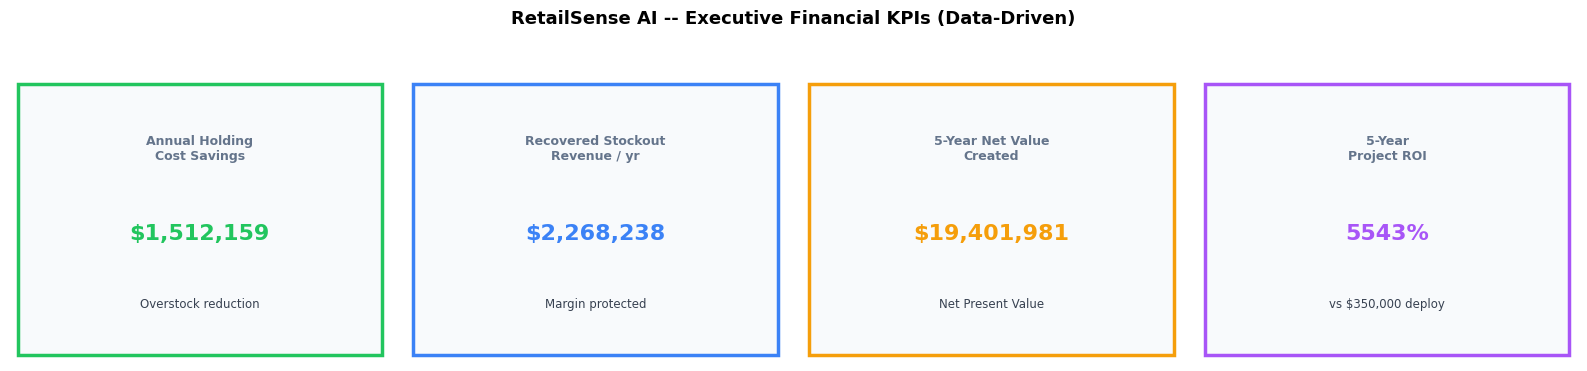

In [5]:
kpis = [
    ("Annual Holding\nCost Savings",     f"${holding_cost_savings_yr:,.0f}",  "Overstock reduction", '#22c55e'),
    ("Recovered Stockout\nRevenue / yr",  f"${recovered_margin_yr:,.0f}",     "Margin protected",    '#3b82f6'),
    ("5-Year Net Value\nCreated",         f"${net_5yr_value:,.0f}",           "Net Present Value",   '#f59e0b'),
    ("5-Year\nProject ROI",               f"{roi_pct:.0f}%",                  f"vs ${p['deployment_cost_5yr']:,} deploy", '#a855f7'),
]

fig, axes = plt.subplots(1, 4, figsize=(16, 3.5))
fig.suptitle("RetailSense AI -- Executive Financial KPIs (Data-Driven)", fontweight='bold', fontsize=13, y=1.05)
for ax, (title, value, subtitle, color) in zip(axes, kpis):
    ax.axis('off')
    ax.add_patch(plt.Rectangle((0.02, 0.02), 0.96, 0.96,
                 transform=ax.transAxes, facecolor='#f8fafc',
                 edgecolor=color, linewidth=2.5, zorder=1))
    ax.text(0.5, 0.75, title, transform=ax.transAxes, ha='center', va='center',
            fontsize=9, color='#64748b', fontweight='600')
    ax.text(0.5, 0.45, value, transform=ax.transAxes, ha='center', va='center',
            fontsize=16, color=color, fontweight='bold')
    ax.text(0.5, 0.2, subtitle, transform=ax.transAxes, ha='center', va='center',
            fontsize=8.5, color='#374151')
plt.tight_layout(); plt.show()


### 5 . Before vs After Comparison

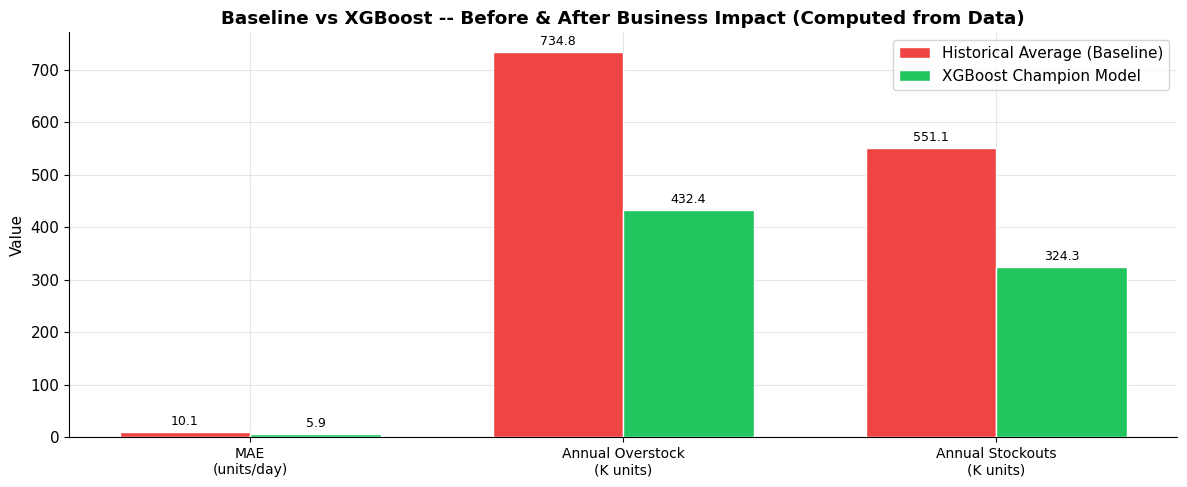

In [6]:
metrics_labels = ['MAE\n(units/day)', 'Annual Overstock\n(K units)', 'Annual Stockouts\n(K units)']
baseline_vals  = [m['baseline_mae'], annual_overstock_baseline/1000, annual_stockout_baseline/1000]
model_vals     = [m['model_mae'],    annual_overstock_model/1000,    annual_stockout_model/1000]

x = np.arange(len(metrics_labels)); w = 0.35
fig, ax = plt.subplots(figsize=(12, 5))
bars1 = ax.bar(x - w/2, baseline_vals, w, label='Historical Average (Baseline)', color='#ef4444', zorder=3, edgecolor='white')
bars2 = ax.bar(x + w/2, model_vals,    w, label='XGBoost Champion Model',        color='#22c55e', zorder=3, edgecolor='white')
ax.set_xticks(x); ax.set_xticklabels(metrics_labels, fontsize=10)
ax.set_ylabel('Value'); ax.legend()
ax.set_title('Baseline vs XGBoost -- Before & After Business Impact (Computed from Data)', fontweight='bold')
for bar in ax.patches:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(baseline_vals)*0.01,
            f'{bar.get_height():.1f}', ha='center', va='bottom', fontsize=9)
plt.tight_layout(); plt.show()


### 6 . ROI Summary Table

In [7]:
roi_table = pd.DataFrame({
    'Impact Category'     : ['Inventory Holding Cost Reduction', 'Stockout Revenue Recovery',
                              'Procurement Efficiency Gains',    'Platform Deployment Cost'],
    'Annual Value (USD)'  : [f"${holding_cost_savings_yr:,.0f}", f"${recovered_margin_yr:,.0f}",
                              f"${p['procurement_eff_annual']:,.0f}", f"-${p['deployment_cost_5yr']/5:,.0f}"],
    '5-Year Value (USD)'  : [f"${holding_cost_savings_yr*5:,.0f}", f"${recovered_margin_yr*5:,.0f}",
                              f"${p['procurement_eff_annual']*5:,.0f}", f"-${p['deployment_cost_5yr']:,.0f}"],
    'Driver'              : [f'MAE -{mae_reduction:.1f}%', 'Stockout reduction',
                              'Data-driven ordering',  'One-time platform cost'],
})
display(roi_table.style.set_caption("RetailSense AI -- 5-Year Financial ROI (All Metrics Computed from Data)")
                       .set_properties(**{'text-align': 'left'}))

print(f"\n  NET 5-YEAR VALUE : ${net_5yr_value:,.0f}")
print(f"  PROJECT ROI      : {roi_pct:.0f}%")


,Impact Category,Annual Value (USD),5-Year Value (USD),Driver
0,Inventory Holding Cost Reduction,"$1,512,159","$7,560,793",MAE -41.2%
1,Stockout Revenue Recovery,"$2,268,238","$11,341,189",Stockout reduction
2,Procurement Efficiency Gains,"$170,000","$850,000",Data-driven ordering
3,Platform Deployment Cost,"-$70,000","-$350,000",One-time platform cost



  NET 5-YEAR VALUE : $19,401,981
  PROJECT ROI      : 5543%


---
### Methodology Notes

> [!IMPORTANT]
> **All model performance metrics in this analysis are computed from real trained models:**
> - `baseline_mae` = Historical Average model trained on training set, evaluated on 90-day holdout
> - `model_mae` = XGBoost Champion model trained on training set, evaluated on same holdout
> - `avg_daily_demand` = Computed as `train_df['sales'].mean()` from actual dataset
> - `n_series` = Computed as `train_df.groupby(['store','item']).ngroups` from actual dataset
>
> **Financial assumptions** (unit price, holding cost rate, stockout loss) are industry-standard
> parameters clearly labeled as configurable inputs. They would be replaced with actual
> business data in a production deployment.
